# WP4 period prior, Mount Gunson-type branch (Annex C)

The third concept beside the sediment-hosted (Annex A) and Middleback (Annex B) branches: stratiform copper of the kind mined at Mount Gunson, the only copper worked on the Stuart Shelf before 1975. Tabular bodies 1 to 5 m thick lie on the post-Pandurra surface in the Woocalla reduced facies, close to the facies edge (the palaeo-shoreline) and in depressions of that surface; no igneous source is required. The basalt piles and iron bodies in this branch are barren objects.

**Shared setting by import.** Level 1 (frame and horsts), the barren piles and iron bodies of Level 2, the Level 5 basement fields and property assembly, the Part 0 rule, the forward operator and the observed surveys are imported from `09_sherlock/svoi_core.py`, as in the Middleback notebook. Only Level 3 (the Woocalla facies at the top of the Pandurra) and Level 4 (the copper bodies) are defined here. For a given seed, Level 1 and the piles are identical in all three branches.

**What is different about this branch.** The trap is the top of the Pandurra, not the basement contact, so the copper is 250 to 350 m shallower than in Annex A; the bodies are 0.05 to 10 Mt, the Mount Gunson scale, not the Copperbelt's tens to hundreds; and nothing in the branch makes an anomaly, so the t0 surveys are indifferent to it. It is the concept under which gravity and magnetics do not help find copper on the shelf.

Run from the `SVOI_OD` folder. Inputs: `01_citation_table/wp4_annexC_citation_table_draft.csv`, `03_sampler_inputs/mount_gunson_t0_dossier.csv`. Outputs: `08_prior_models/mountgunson/`.

1. Setup: figure style, the shared core, the Annex C rows
2. Part A. The branch (Steps 0 to 4): the facies and copper stages; level figures; the five levels on one section; the 50-realization row check
3. Part B. Prior predictive check (Steps 5 to 8)
4. Part C. Versioned record (Step 9)


In [1]:
# --- journal figure style ---------------------------------------------------
# Every text element has an explicit size; figures are drawn at final printed
# width so the point sizes below are the sizes that reach the page.
import matplotlib.pyplot as plt

FS_TICK, FS_LABEL, FS_LEGEND, FS_ANNOT, FS_PANEL = 8, 9, 8, 7, 9
COL1, COL15, COL2 = 3.5, 5.5, 7.2      # single / 1.5 / double column width (in)

plt.rcParams.update({
    # typeface
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": FS_TICK,
    # text elements
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_PANEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.title_fontsize": FS_LEGEND,
    "figure.titlesize": FS_LABEL,
    # axes furniture: thin frame, ticks inward on all four sides, minor ticks
    "axes.linewidth": 0.6,
    "axes.grid": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4, "ytick.minor.width": 0.4,
    "xtick.major.size": 3.0, "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8, "ytick.minor.size": 1.8,
    # marks
    "lines.linewidth": 1.0,
    "lines.markersize": 3.0,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.borderaxespad": 0.4,
    # output
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

def panel_labels(axes, labels=("(a)", "(b)")):
    """Bold (a)/(b) above the top-left corner of each axes."""
    for ax, lab in zip(axes, labels):
        ax.set_title(lab, loc="left", fontsize=FS_PANEL, fontweight="bold")

# --- batlow: Crameri's scientific colour map (Crameri et al. 2020, Nat. Commun.)
# 32 anchor points interpolated to 256 steps; reproduces the published map to
# within 1.4/255 per channel. Embedded so the notebook needs no extra package.
from matplotlib.colors import LinearSegmentedColormap
_BATLOW = [
    (0.0052, 0.0982, 0.3498), (0.0321, 0.1468, 0.3582), (0.0494, 0.1911, 0.3658), (0.0592, 0.2298, 0.3723),
    (0.0679, 0.2671, 0.3782), (0.0771, 0.2970, 0.3824), (0.0903, 0.3257, 0.3849), (0.1097, 0.3531, 0.3842),
    (0.1413, 0.3812, 0.3771), (0.1778, 0.4030, 0.3638), (0.2201, 0.4219, 0.3443), (0.2662, 0.4386, 0.3201),
    (0.3208, 0.4560, 0.2898), (0.3709, 0.4711, 0.2621), (0.4225, 0.4861, 0.2345), (0.4762, 0.5013, 0.2081),
    (0.5402, 0.5186, 0.1831), (0.6005, 0.5336, 0.1706), (0.6627, 0.5475, 0.1740), (0.7243, 0.5596, 0.1954),
    (0.7906, 0.5714, 0.2362), (0.8457, 0.5817, 0.2826), (0.8958, 0.5938, 0.3379), (0.9378, 0.6096, 0.4023),
    (0.9708, 0.6324, 0.4833), (0.9864, 0.6555, 0.5571), (0.9923, 0.6790, 0.6283), (0.9930, 0.7020, 0.6958),
    (0.9914, 0.7276, 0.7703), (0.9891, 0.7510, 0.8380), (0.9860, 0.7753, 0.9084), (0.9814, 0.8004, 0.9813),
]
BATLOW = LinearSegmentedColormap.from_list("batlow", _BATLOW, N=256)

import matplotlib.patheffects as _pe
HALO = [_pe.withStroke(linewidth=1.6, foreground="white")]   # keeps markers and
# labels legible where they sit on a filled colour field


## Data and the shared core

In [2]:
import sys, io, contextlib, re, json, time, hashlib, datetime
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import ndimage

sys.path.insert(0, "09_sherlock")
with contextlib.redirect_stdout(io.StringIO()):
    import svoi_core as C
PM = Path("."); assert (PM / "01_citation_table").is_dir(), "run from the SVOI_OD folder"
OUT = Path("08_prior_models/mountgunson"); FIG = OUT / "figures"; FIG.mkdir(parents=True, exist_ok=True)
CC = pd.read_csv(PM / "01_citation_table/wp4_annexC_citation_table_draft.csv").set_index("row_id")
DOSS = pd.read_csv(PM / "03_sampler_inputs/mount_gunson_t0_dossier.csv")

def cited_c(row, *numbers):
    """every number the code uses for an Annex C row must be written in that row; the status is reported, not asserted"""
    txt = CC.loc[row, "proposed_distribution"].replace(",", "")
    written = {float(x) for x in re.findall(r"\d+\.?\d*", txt)}
    for v in numbers:
        assert float(v) in written, (row, v, txt)
    return CC.loc[row, "status"]

print(f"shared core: grid {C.NX} x {C.NY} km; {len(C.G_OBS)} gravity stations, {len(C.M_OBS):,} magnetic readings; Annex A rows {len(C.CT)}")
print(f"Annex C rows: {len(CC)}; dossier statements: {len(DOSS)} (pre-t0: {(DOSS.status_t0 == 'before').sum()})"); print(CC[["parameter", "status"]].to_string())


shared core: grid 147 x 115 km; 398 gravity stations, 37,095 magnetic readings; Annex A rows 17
Annex C rows: 7; dossier statements: 37 (pre-t0: 36)
                                                                                                 parameter                  status
row_id                                                                                                                            
C3-1                                         P(Woocalla reduced facies present at the top of the Pandurra)  translated; to confirm
C3-2                             Woocalla basin geometry: belt length; aspect; strike; depression coupling  translated; to confirm
C4-1    Favourable zone: distance from the reduced facies edge (shoreline) within which copper bodies form  translated; to confirm
C4-2                                                          Copper body intensity in the favourable zone  translated; to confirm
C4-3                                                            C

## Part A. The branch

`realize_mg(seed)` draws the shared Annex A quantities with `C.draw` (frame, barren piles, iron bodies, cover and basement properties) in the same stream order as the other branches; the Annex C rows are drawn inside their stages. Stage order: frame, piles, facies, copper, iron bodies, basement fields.

1. **Level 1, frame** [Annex A, Change 9]: imported. The top of the Pandurra, $s_4(\mathbf{x})$, is the surface this branch works on.
2. **Level 2, objects** [Annex A]: barren basalt piles and iron bodies, imported unchanged. This branch adds no object of its own: the Woocalla black shale is a facies of the cover, not a body with a contrast.
3. **Level 3, the Woocalla facies.** Reduced facies at the top of the Pandurra is the exceedance set of $g(\mathbf{x};\ \ell_b/3, \ell_b/9.6, 10^\circ) + z_{dep}(\mathbf{x})$, with $\ell_b \sim$ LogU(30, 150) km and the Mount Gunson corridor's aspect and strike [C3-2], and $z_{dep}$ the standardized depth of $s_4$ below its 20 km running mean, so that the facies prefers depressions of the post-Pandurra surface (Maiden 1974); the sum is cut at its $(1-p)$ quantile with $p \sim$ U(0.15, 0.50) [C3-1], a far higher presence than Annex A's because this facies is known in the window (Woomera No. 1, the LD holes).
4. **Level 4, the copper bodies.** The favourable zone is the reduced facies within reach $d_c \sim$ LogU(1, 15) km of its own edge, the palaeo-shoreline where Cu is highest and falls off over 15 km [C4-1]: the Mount Gunson margin is the facies edge, as the basalt edge is Annex A's. Bodies are a Poisson number at LogU(50, 300) per $10^4$ km$^2$ of zone [C4-2], placed uniformly in it, each tabular on $s_4$ with plan area LogU(0.02, 1) km$^2$ and thickness LogU(1, 5) m [C4-3] and grade U(1, 3.5)% Cu [C4-4]; tonnage is area times thickness times host density, derived.
5. **Level 5, properties** [Annex A; C5-1]: imported. The copper bodies add a few hundredths of a g/cm$^3$ over a few metres and are not written into the volume: this branch is invisible to both surveys by construction.

Declared settings without a row: the depression weight (1), the 20 km running mean that defines a depression, no lineament weighting (the targets were drawn for the basalt concept; Mount Gunson's own control was the Pernatty Culmination, a basement high, which the depression term stands in for inversely).


In [3]:
U, LU = C.U, C.LU
for row, nums in [("C3-1", (0.15, 0.50)), ("C3-2", (30, 150, 3.2, 10, 20, 1)), ("C4-1", (1, 15)), ("C4-2", (50, 300)), ("C4-3", (0.02, 1.0, 1, 5)), ("C4-4", (1.0, 3.5))]:
    print(f"{row}: {cited_c(row, *nums)}")
FIX_MG = dict(belt_aspect=3.2, belt_az=10.0, dep_weight=1.0, dep_window_km=20.0)   # declared: Mount Gunson corridor (RB 72/00189), depression term (PMR 58/74)
A_UNUSED = [k for k in C.draw(np.random.default_rng(0)) if k[:2] in ("L3", "L4")]

def draw_mg(r):
    p = C.draw(r)
    for k in A_UNUSED: p.pop(k)
    return p

def level3_woocalla(r, p, F):
    """reduced facies at the top of the Pandurra: the Annex A anisotropic field plus a depression term of s4"""
    p["C3-1 p_reduced"] = U(r, 0.15, 0.50); p["C3-2 belt_length_km"] = LU(r, 30, 150)
    Lb = p["C3-2 belt_length_km"]
    g = C.grf(r, Lb / 3.0, Lb / 3.0 / FIX_MG["belt_aspect"], FIX_MG["belt_az"])
    s4 = F["s4"]; dep = ndimage.uniform_filter(s4, size=int(FIX_MG["dep_window_km"])) - s4      # positive where the Pandurra top is shallower than its surroundings
    dep = -dep; dep = (dep - dep.mean()) / dep.std()                                              # positive in depressions, unit variance
    f = g + FIX_MG["dep_weight"] * dep
    return dict(reduced=f >= np.quantile(f, 1 - p["C3-1 p_reduced"]), dep=dep)

def level4_copper(r, p, F):
    p["C4-1 reach_km"] = LU(r, 1, 15); p["C4-2 body_intensity_per_1e4km2"] = LU(r, 50, 300)
    red = F["reduced"]
    if red.any() and (~red).any():
        dist_edge = ndimage.distance_transform_edt(red) * C.DX / 1e3                              # km inside the facies from its edge
        zone = red & (dist_edge <= p["C4-1 reach_km"])
    else:
        zone = red.copy()
    zone_km2 = zone.sum() * (C.DX / 1e3) ** 2
    n = r.poisson(p["C4-2 body_intensity_per_1e4km2"] * zone_km2 / 1e4) if zone.any() else 0
    ox, oy = C.weighted_points(r, n, np.ones((C.NY, C.NX)), zone)
    ores = []; host = p["L5-2 rho_pandurra"]
    for x, y in zip(ox, oy):
        A = LU(r, 0.02, 1.0); th = LU(r, 1, 5); G = U(r, 1.0, 3.5)
        iy_, ix_ = np.argmin(abs(C.YC - y)), np.argmin(abs(C.XC - x))
        vf = G / 100 / C.FIX["cu_in_ccp"] * host / C.FIX["rho_ccp"]; drho = vf * (C.FIX["rho_ccp"] - host)
        ores.append(dict(x=x, y=y, iy=int(iy_), ix=int(ix_), area_km2=A, thick_m=th, grade=G, drho=drho, depth_m=float(F["s4"][iy_, ix_]),
                         Mt=A * th * (host + drho), dist_edge_km=float(dist_edge[iy_, ix_]) if red.any() and (~red).any() else np.nan))
    return dict(zone=zone, ores=ores)

def mg_summary(p, F):
    O = F["ores"]
    return {"L5-4 basement_sd": F["basement_sd"], "L5-4 basement_logk_sd": F["basement_logk_sd"],
            **dict(n_basalt=len(F["objs"]), basalt_frac=F["basalt"].mean(), n_iron=len(F["irons"]), reduced_frac=F["reduced"].mean(),
                   zone_km2=F["zone"].sum() * (C.DX / 1e3) ** 2, n_ore=len(O), Mt_total=sum(o["Mt"] for o in O), Mt_max=max([o["Mt"] for o in O], default=0.0),
                   ore_depth_median=float(np.median([o["depth_m"] for o in O])) if O else np.nan, basement_sd_realized=F["rho_base"].std())}

BRANCH_MG = dict(name="Mount Gunson-type stratiform Cu, Annex C", citation_table="01_citation_table/wp4_annexC_citation_table_draft.csv",
                 geometry_family="flat-lying cover stack; barren piles and iron bodies; Woocalla reduced facies at the top of the Pandurra in depressions",
                 mineralization_rule="tabular Cu bodies on the post-Pandurra surface inside the reduced facies within reach of its edge; no igneous source",
                 draw=draw_mg, stages=[C.level1_frame, C.level2_basalt, level3_woocalla, level4_copper, C.level2_iron, C.level5_basement],
                 properties=C.level5_properties, summary=mg_summary)

def realize_mg(seed, keep_volume=False):
    return C.realize_branch(BRANCH_MG, seed, keep_volume)

def synthetic_mg(seed, rng_noise=True):
    out, maps, objs, ores = realize_mg(seed, keep_volume=True)
    g, t = C.forward(maps["rho"], maps["k"])
    r = np.random.default_rng(seed + 10_000_000)
    gs = C.sample(g, C.GXo, C.GYo) + (r.normal(0, C.G_SD) if rng_noise else 0)
    ms = C.sample(t, C.MXo, C.MYo) + (r.normal(0, C.RULE["mag_noise_nt"], len(C.MXo)) if rng_noise else 0)
    return out, maps, g, t, gs, ms

o43, m43, b43, e43 = realize_mg(43)
oA, mA, bA, _ = C.realize(43)
print("branch:", BRANCH_MG["name"]); print("  stages:", [f.__name__ for f in BRANCH_MG["stages"]], "+", BRANCH_MG["properties"].__name__)
print(f"seed 43: Level 1 identical to the other branches: {np.array_equal(m43['base'], mA['base'])}; piles identical: {len(b43) == len(bA) and np.allclose(b43[['x', 'y', 'length_km']].values, bA[['x', 'y', 'length_km']].values)}")
print(f"seed 43: reduced facies {o43['reduced_frac']*100:.0f}% of the window, zone {o43['zone_km2']:.0f} km2, {o43['n_ore']} Cu bodies, {o43['Mt_total']:.1f} Mt, median depth {o43['ore_depth_median']:.0f} m")


C3-1: translated; to confirm
C3-2: translated; to confirm
C4-1: translated; to confirm
C4-2: translated; to confirm
C4-3: translated; to confirm
C4-4: translated; to confirm
branch: Mount Gunson-type stratiform Cu, Annex C
  stages: ['level1_frame', 'level2_basalt', 'level3_woocalla', 'level4_copper', 'level2_iron', 'level5_basement'] + level5_properties
seed 43: Level 1 identical to the other branches: True; piles identical: True
seed 43: reduced facies 24% of the window, zone 2037 km2, 9 Cu bodies, 19.8 Mt, median depth 301 m


### Step 0. Prior distributions

One panel per sampled quantity, in level order and coloured by level: the shared rows L and this branch's rows C.

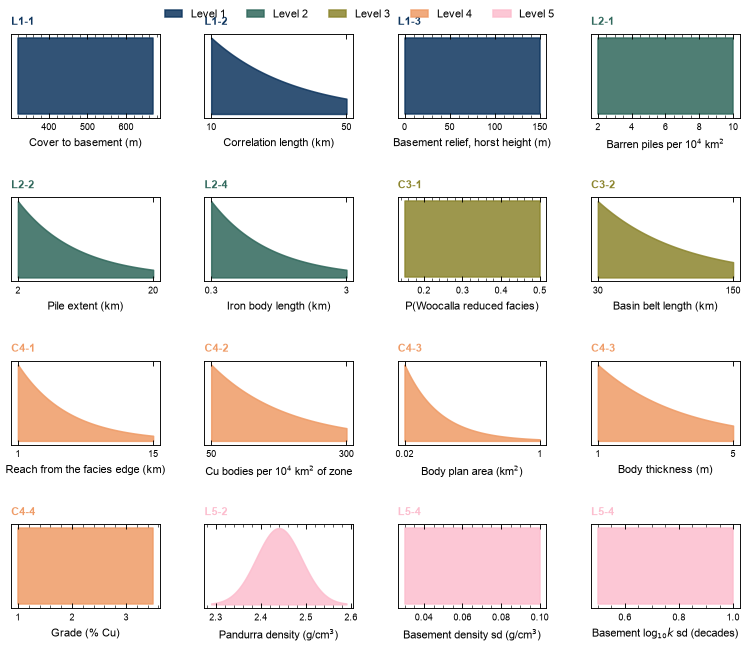

every C row is a range translated from the Mount Gunson dossier; none is a mode; C5-1 is derived and has no panel


In [4]:
PANELS_C = [("C3-1", "P(Woocalla reduced facies)", ("u", 0.15, 0.50)), ("C3-2", "Basin belt length (km)", ("lu", 30, 150)),
            ("C4-1", "Reach from the facies edge (km)", ("lu", 1, 15)), ("C4-2", "Cu bodies per 10$^4$ km$^2$ of zone", ("lu", 50, 300)),
            ("C4-3", "Body plan area (km$^2$)", ("lu", 0.02, 1.0)), ("C4-3", "Body thickness (m)", ("lu", 1, 5)), ("C4-4", "Grade (% Cu)", ("u", 1.0, 3.5))]
PANELS_A = [("L1-1", "Cover to basement (m)", ("u", 320, 670)), ("L1-2", "Correlation length (km)", ("lu", 10, 50)), ("L1-3", "Basement relief, horst height (m)", ("u", 0, 150)),
            ("L2-1", "Barren piles per 10$^4$ km$^2$", ("u", 2, 10)), ("L2-2", "Pile extent (km)", ("lu", 2, 20)), ("L2-4", "Iron body length (km)", ("lu", 0.3, 3)),
            ("L5-2", "Pandurra density (g/cm$^3$)", ("n", 2.44, 0.05)), ("L5-4", "Basement density sd (g/cm$^3$)", ("u", 0.03, 0.10)), ("L5-4", "Basement log$_{10}k$ sd (decades)", ("u", 0.5, 1.0))]
LEVEL_COL = {k: BATLOW(v) for k, v in zip(range(1, 6), (0.08, 0.30, 0.52, 0.74, 0.92))}
from matplotlib.ticker import FormatStrFormatter
PANELS = sorted(PANELS_A + PANELS_C, key=lambda t: (int(t[0][1]), t[0][0] == "C"))
fig, axes = plt.subplots(4, 4, figsize=(COL2, 6.0)); fig.subplots_adjust(left=0.06, right=0.98, top=0.95, bottom=0.08, wspace=0.3, hspace=0.95)
for ax in axes.ravel()[len(PANELS):]: ax.set_visible(False)
for ax, (row, lab, d) in zip(axes.ravel(), PANELS):
    col = LEVEL_COL[int(row[1])]
    if d[0] == "u":
        x = np.linspace(d[1], d[2], 2); ax.fill_between(x, 0, 1 / (d[2] - d[1]), color=col, alpha=0.85)
    elif d[0] == "n":
        x = np.linspace(d[1] - 3 * d[2], d[1] + 3 * d[2], 100); ax.fill_between(x, 0, np.exp(-0.5 * ((x - d[1]) / d[2]) ** 2), color=col, alpha=0.85)
    else:
        x = np.geomspace(d[1], d[2], 100); ax.fill_between(x, 0, 1 / (x * np.log(d[2] / d[1])), color=col, alpha=0.85); ax.set_xscale("log")
        ax.set_xticks([d[1], d[2]], minor=False); ax.set_xticks([], minor=True); ax.xaxis.set_major_formatter(FormatStrFormatter("%g"))
    ax.set_yticks([]); ax.set_xlabel(lab, fontsize=FS_ANNOT); ax.tick_params(labelsize=FS_ANNOT - 1)
    ax.set_title(row, loc="left", fontsize=FS_ANNOT, color=col, fontweight="bold")
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=LEVEL_COL[k], alpha=0.85, label=f"Level {k}") for k in (1, 2, 3, 4, 5)], loc="upper center", ncol=5, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.0), frameon=False)
fig.savefig(FIG / "wp4_MG_00_priors.png", dpi=300); plt.show()
print("every C row is a range translated from the Mount Gunson dossier; none is a mode; C5-1 is derived and has no panel")


**Reading the figure.** Uniform on a linear axis, log-uniform on a log axis, one shaped prior (the Pandurra density). Levels 1, 2 and 5 are the shared rows; this branch's own rows are the Level 3 facies (C3) and the Level 4 copper bodies (C4). P(reduced) is 0.15 to 0.50 against Annex A's 0.05 to 0.30: the Woocalla facies is known in the window, Annex A's contact facies was not. None of the C rows is yet confirmed against its source.

### Step 1. Level 3: the Woocalla facies at the top of the Pandurra (seeds 43, 77, 99)

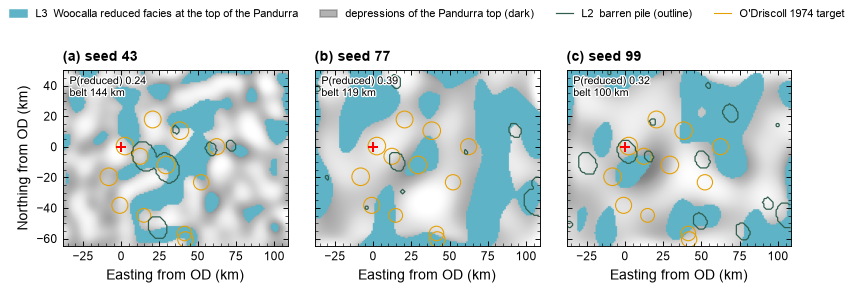

seed 43: reduced 24% of the window (drawn 0.24); mean depression score inside the facies +0.99 against -0.32 outside
seed 77: reduced 39% of the window (drawn 0.39); mean depression score inside the facies +0.64 against -0.41 outside
seed 99: reduced 32% of the window (drawn 0.32); mean depression score inside the facies +0.84 against -0.40 outside


In [5]:
OUT_, MAPS, OBJ, ORE = {}, {}, {}, {}
for s in (43, 77, 99):
    OUT_[s], MAPS[s], OBJ[s], ORE[s] = realize_mg(s, keep_volume=True)
ODX, ODY, XC, YC, X0, X1, Y0, Y1 = C.ODX, C.ODY, C.XC, C.YC, C.X0, C.X1, C.Y0, C.Y1
ext = [(X0 - ODX) / 1e3, (X1 - ODX) / 1e3, (Y0 - ODY) / 1e3, (Y1 - ODY) / 1e3]; xkm = (XC - ODX) / 1e3
iy = int(np.argmin(abs(YC - ODY)))
C_MG = dict(basalt="#2e5e4e", iron="#1a1a1a", reduced="#5fb3c6", zone="#f3c9c3", ore="#20306f", target="#e69f00")
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.7)); fig.subplots_adjust(left=0.07, right=0.99, top=0.82, bottom=0.14, wspace=0.12)
for ax, s in zip(axes, (43, 77, 99)):
    m = MAPS[s]; o = OUT_[s]
    ax.imshow(m["dep"], origin="lower", extent=ext, cmap="Greys", vmin=-2.5, vmax=2.5, alpha=0.5, aspect="equal")
    ax.imshow(np.where(m["reduced"], 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap([C_MG["reduced"]]), aspect="equal")
    ax.contour(xkm, (YC - ODY) / 1e3, (m["bid"] > 0).astype(float), levels=[0.5], colors=C_MG["basalt"], linewidths=0.8)
    for x, y, rr in zip(C.TX, C.TYY, C.TG.radius_km.values):
        ax.add_patch(plt.Circle(((x - ODX) / 1e3, (y - ODY) / 1e3), rr, fill=False, ec=C_MG["target"], lw=0.7))
    ax.plot(0, 0, "+", color="red", ms=7, mew=1.3); ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_xlabel("Easting from OD (km)")
    ax.text(0.03, 0.97, f"P(reduced) {o['C3-1 p_reduced']:.2f}\nbelt {o['C3-2 belt_length_km']:.0f} km", transform=ax.transAxes, va="top", fontsize=FS_ANNOT, path_effects=HALO)
axes[0].set_ylabel("Northing from OD (km)")
for ax in axes[1:]: ax.set_yticklabels([])
panel_labels(axes, ("(a) seed 43", "(b) seed 77", "(c) seed 99"))
h = [plt.Rectangle((0, 0), 1, 1, color=C_MG["reduced"], label="L3  Woocalla reduced facies at the top of the Pandurra"), plt.Rectangle((0, 0), 1, 1, color="0.4", alpha=0.5, label="depressions of the Pandurra top (dark)"),
     plt.Line2D([], [], color=C_MG["basalt"], lw=0.8, label="L2  barren pile (outline)"), plt.Line2D([], [], color=C_MG["target"], lw=0.7, label="O'Driscoll 1974 target")]
fig.legend(handles=h, loc="upper center", ncol=4, fontsize=FS_ANNOT, bbox_to_anchor=(0.53, 1.01), frameon=False)
fig.savefig(FIG / "wp4_MG_01_woocalla_facies.png", dpi=300); plt.show()
for s in (43, 77, 99):
    o, m = OUT_[s], MAPS[s]
    print(f"seed {s}: reduced {o['reduced_frac']*100:.0f}% of the window (drawn {o['C3-1 p_reduced']:.2f}); mean depression score inside the facies {m['dep'][m['reduced']].mean():+.2f} against {m['dep'][~m['reduced']].mean():+.2f} outside")


**Reading the figure.** Teal is the reduced facies, drawn on the depression score of the Pandurra top (dark where the surface is lower than its 20 km surroundings), green outlines the barren piles, amber the 1974 targets.
- Seeds 43, 77, 99: reduced 24, 39 and 32% of the window (the drawn P by construction). The facies keeps the Mount Gunson fabric (north-south belts) and is pulled toward the depressions: mean depression score +0.99, +0.64 and +0.84 inside the facies against -0.32 to -0.41 outside, with the belt field and the depression term weighted equally.
- At 15 to 50% the facies covers far more of the window than Annex A's 5 to 30%, which is what the LD holes (6 of 7) and Woomera No. 1 support; it is the branch's most consequential row after C4-2.

### Step 2. Level 4: the favourable zone and the copper bodies

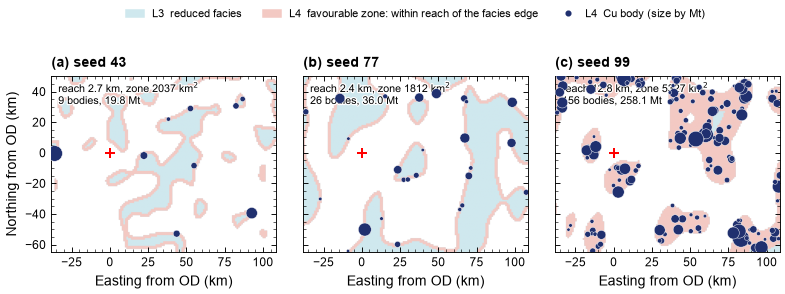

seed 43: zone 2037 km2, 9 bodies, 0.32-8.3 Mt each (total 19.8), thickness 1.1-4.3 m, grade 1.4-3.2%, depth 221-395 m; Mount Gunson: bodies of 0.03 to 3 Mt, field total about 3 Mt
seed 77: zone 1812 km2, 26 bodies, 0.06-5.7 Mt each (total 36.0), thickness 1.0-4.9 m, grade 1.1-3.4%, depth 211-454 m; Mount Gunson: bodies of 0.03 to 3 Mt, field total about 3 Mt
seed 99: zone 5327 km2, 156 bodies, 0.06-9.8 Mt each (total 258.1), thickness 1.0-5.0 m, grade 1.0-3.5%, depth 167-352 m; Mount Gunson: bodies of 0.03 to 3 Mt, field total about 3 Mt


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.7)); fig.subplots_adjust(left=0.07, right=0.99, top=0.80, bottom=0.14, wspace=0.12)
for ax, s in zip(axes, (43, 77, 99)):
    m = MAPS[s]; e = ORE[s]; o = OUT_[s]
    ax.imshow(np.where(m["reduced"], 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap(["#cfe8ee"]), aspect="equal")
    ax.imshow(np.where(m["zone"], 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap([C_MG["zone"]]), aspect="equal")
    if len(e): ax.scatter((e.x - ODX) / 1e3, (e.y - ODY) / 1e3, s=4 + 12 * e.Mt, c=C_MG["ore"], edgecolors="white", linewidths=0.3, zorder=4)
    ax.plot(0, 0, "+", color="red", ms=7, mew=1.3); ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_xlabel("Easting from OD (km)")
    ax.text(0.03, 0.97, f"reach {o['C4-1 reach_km']:.1f} km, zone {o['zone_km2']:.0f} km$^2$\n{o['n_ore']} bodies, {o['Mt_total']:.1f} Mt", transform=ax.transAxes, va="top", fontsize=FS_ANNOT, path_effects=HALO)
axes[0].set_ylabel("Northing from OD (km)")
for ax in axes[1:]: ax.set_yticklabels([])
panel_labels(axes, ("(a) seed 43", "(b) seed 77", "(c) seed 99"))
h = [plt.Rectangle((0, 0), 1, 1, color="#cfe8ee", label="L3  reduced facies"), plt.Rectangle((0, 0), 1, 1, color=C_MG["zone"], label="L4  favourable zone: within reach of the facies edge"),
     plt.Line2D([], [], color=C_MG["ore"], marker="o", ls="", label="L4  Cu body (size by Mt)")]
fig.legend(handles=h, loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.53, 1.02), frameon=False)
fig.savefig(FIG / "wp4_MG_02_copper_bodies.png", dpi=300); plt.show()
for s in (43, 77, 99):
    e = ORE[s]
    print(f"seed {s}: zone {OUT_[s]['zone_km2']:.0f} km2, {len(e)} bodies" + (f", {e.Mt.min():.2f}-{e.Mt.max():.1f} Mt each (total {e.Mt.sum():.1f}), thickness {e.thick_m.min():.1f}-{e.thick_m.max():.1f} m, grade {e.grade.min():.1f}-{e.grade.max():.1f}%, depth {e.depth_m.min():.0f}-{e.depth_m.max():.0f} m; Mount Gunson: bodies of 0.03 to 3 Mt, field total about 3 Mt" if len(e) else ""))


**Reading the figure.** Pale blue the reduced facies, pink the favourable zone (the band inside the facies within reach of its edge, the palaeo-shoreline), navy the copper bodies sized by tonnage.
- Seeds 43, 77, 99: zones of 2,037, 1,812 and 5,327 km$^2$; 9, 26 and 156 bodies of 0.3 to 8.3, 0.06 to 5.7 and 0.06 to 9.8 Mt (totals 20, 36 and 258 Mt); 1 to 5 m thick, 1.0 to 3.5% Cu, on the Pandurra top at 167 to 454 m.
- The Mount Gunson field for comparison: Sweet Nell 0.2 Mt, East Lagoon 0.25 Mt, the open-cut reserve 3 Mt. The bodies are that size; their number follows the zone area through C4-2, and a 5,000 km$^2$ zone gives a district with far more copper bodies than the shelf was known to hold, which is the row to test first.

### Step 3. The five levels on one section

The west-east line at the Olympic Dam northing, for the seed among 100 to 399 whose line crosses the most copper bodies (stated rule). The trap here is the top of the Pandurra, drawn with the reduced band on that surface; the bodies sit on it, drawn at least 25 m thick (their real thickness is 1 to 5 m). The basement unconformity carries no facies in this branch.

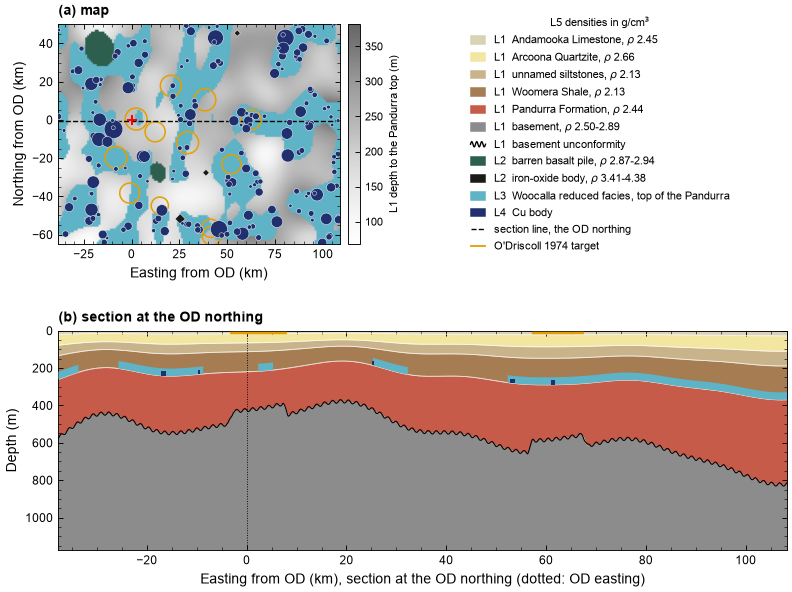

seed 277 (rule: most Cu bodies on the OD-northing line among seeds 100-399): 6 bodies on the line at +61, +108, -10, +53, -17, +25 km east, 0.19-5.84 Mt, on the Pandurra top at 186-369 m; reduced facies on 93 km of line; piles over 0 km
window: reduced 45%, zone 6604 km2, 194 bodies, 289.3 Mt; relief draw 66 m


In [7]:
def bodies_on_line(s):
    o, m, _, e = realize_mg(s); return int((e.iy == iy).sum()) if len(e) else 0
cand = sorted(((bodies_on_line(s), s) for s in range(100, 400)), reverse=True)
S5 = cand[0][1]; o5, m5, b5, e5 = realize_mg(S5, keep_volume=True)
UNIT_COL = {1: "#d9d2b5", 2: "#f2e6a0", 3: "#c9b38a", 4: "#a67c52", 5: "#c75b4a", 6: "#2e5e4e", 7: "#8c8c8c"}
def unconformity(ax, x, y, amp=9.0, wl=1.6, **kw):
    xf = np.linspace(x[0], x[-1], len(x) * 8); yf = np.interp(xf, x, y) + amp * np.sin(2 * np.pi * xf / wl); ax.plot(xf, yf, **{"color": "k", "lw": 0.7, **kw})
from matplotlib.legend_handler import HandlerBase
class WavyHandler(HandlerBase):
    def create_artists(self, legend, orig, xdescent, ydescent, width, height, fontsize, trans):
        x = np.linspace(0, width, 60); y = height / 2 + 0.35 * height * np.sin(2 * np.pi * x / (width / 3))
        line = plt.Line2D(x - xdescent, y - ydescent, color=orig.get_color(), lw=orig.get_linewidth()); line.set_transform(trans); return [line]
UNCONF_KEY = plt.Line2D([], [], color="k", lw=0.9)
fig = plt.figure(figsize=(COL2, 5.6))
gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1.0], hspace=0.30, wspace=0.42, left=0.07, right=0.99, top=0.96, bottom=0.08)
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(m5["cover"], origin="lower", extent=ext, cmap="Greys", alpha=0.6, aspect="equal")
ax.imshow(np.where(m5["reduced"], 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap([C_MG["reduced"]]), aspect="equal")
ax.imshow(np.where(m5["bid"] > 0, 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap([C_MG["basalt"]]), aspect="equal")
ir5 = pd.DataFrame(m5["irons"])
if len(ir5): ax.scatter((ir5.x - ODX) / 1e3, (ir5.y - ODY) / 1e3, s=6 + 8 * ir5.length_km, marker="D", c=C_MG["iron"], edgecolors="white", linewidths=0.3, zorder=4)
if len(e5): ax.scatter((e5.x - ODX) / 1e3, (e5.y - ODY) / 1e3, s=4 + 12 * e5.Mt, c=C_MG["ore"], edgecolors="white", linewidths=0.3, zorder=5)
for x, y, rr in zip(C.TX, C.TYY, C.TG.radius_km.values): ax.add_patch(plt.Circle(((x - ODX) / 1e3, (y - ODY) / 1e3), rr, fill=False, ec=C_MG["target"], lw=1.0))
ax.axhline((YC[iy] - ODY) / 1e3, color="k", lw=0.9, ls="--"); ax.plot(0, 0, "+", color="red", ms=7, mew=1.3)
ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_xlabel("Easting from OD (km)"); ax.set_ylabel("Northing from OD (km)")
from mpl_toolkits.axes_grid1 import make_axes_locatable
cax = make_axes_locatable(ax).append_axes("right", size="4%", pad=0.08); cb = fig.colorbar(im, cax=cax); cb.set_label("L1 depth to the Pandurra top (m)", fontsize=FS_ANNOT); cb.ax.tick_params(labelsize=FS_ANNOT); cb.ax.yaxis.set_minor_locator(plt.NullLocator())
axl = fig.add_subplot(gs[0, 1]); axl.axis("off"); R = lambda **kw: plt.Rectangle((0, 0), 1, 1, **kw)
H = [R(color=UNIT_COL[1], label=f"L1  {C.LITH[1]}, $\\rho$ {o5['L5-2 rho_limestone']:.2f}"), R(color=UNIT_COL[2], label=f"L1  {C.LITH[2]}, $\\rho$ {o5['L5-2 rho_quartzite']:.2f}"),
     R(color=UNIT_COL[3], label=f"L1  {C.LITH[3]}, $\\rho$ {o5['L5-2 rho_shale']:.2f}"), R(color=UNIT_COL[4], label=f"L1  {C.LITH[4]}, $\\rho$ {o5['L5-2 rho_shale']:.2f}"),
     R(color=UNIT_COL[5], label=f"L1  {C.LITH[5]}, $\\rho$ {o5['L5-2 rho_pandurra']:.2f}"), R(color=UNIT_COL[7], label=f"L1  basement, $\\rho$ {m5['rho_base'].min():.2f}-{m5['rho_base'].max():.2f}"),
     UNCONF_KEY,
     R(color=C_MG["basalt"], label=f"L2  barren basalt pile, $\\rho$ {b5.rho.min():.2f}-{b5.rho.max():.2f}" if len(b5) else "L2  barren basalt pile"),
     R(color=C_MG["iron"], label=f"L2  iron-oxide body, $\\rho$ {ir5.rho.min():.2f}-{ir5.rho.max():.2f}" if len(ir5) else "L2  iron-oxide body"),
     R(color=C_MG["reduced"], label="L3  Woocalla reduced facies, top of the Pandurra"),
     R(color=C_MG["ore"], label="L4  Cu body"),
     plt.Line2D([], [], color="k", lw=0.9, ls="--", label="section line, the OD northing"), plt.Line2D([], [], color=C_MG["target"], lw=1.2, label="O'Driscoll 1974 target")]
LAB = [h.get_label() for h in H]; LAB[H.index(UNCONF_KEY)] = "L1  basement unconformity"
axl.legend(handles=H, labels=LAB, handler_map={UNCONF_KEY: WavyHandler()}, loc="center left", bbox_to_anchor=(-0.08, 0.5), fontsize=FS_ANNOT, frameon=False, handlelength=1.4, labelspacing=0.6, title="L5 densities in g/cm$^3$", title_fontsize=FS_ANNOT)
ax = fig.add_subplot(gs[1, :])
tops = [np.zeros(C.NX), m5["s1"][iy], m5["s2"][iy], m5["s3"][iy], m5["cover"][iy], m5["base"][iy]]
for c_ in range(1, 6): ax.fill_between(xkm, tops[c_ - 1], tops[c_], color=UNIT_COL[c_], lw=0)
ax.fill_between(xkm, m5["base"][iy], 5000, color=UNIT_COL[7], lw=0)
for arr in tops[1:-1]: ax.plot(xkm, arr, color="white", lw=0.5, alpha=0.9)
unconformity(ax, xkm, m5["base"][iy], zorder=5)
bs = ~np.isnan(m5["btop"][iy]); ax.fill_between(xkm, np.where(bs, m5["btop"][iy], m5["base"][iy]), m5["base"][iy], where=bs, color=C_MG["basalt"], lw=0, zorder=2)
isec = m5["iid"][iy] > 0; ax.fill_between(xkm, m5["base"][iy], m5["base"][iy] + C.FIX["iron_thick_m"], where=isec, color=C_MG["iron"], lw=0, zorder=2)
top4 = m5["cover"][iy]; red5 = m5["reduced"][iy]
ax.fill_between(xkm, top4 - 40.0, top4, where=red5, color=C_MG["reduced"], lw=0, zorder=3)                 # L3: the Woocalla facies, a band resting on the Pandurra top (40 m drawn)
for o in e5.itertuples():
    if o.iy == iy: ax.add_patch(plt.Rectangle((xkm[o.ix] - 0.5 * np.sqrt(o.area_km2), top4[o.ix] - max(o.thick_m, 25.0)), max(np.sqrt(o.area_km2), 0.4), max(o.thick_m, 25.0), color=C_MG["ore"], lw=0, zorder=4))
for x, y, rr in zip(C.TX, C.TYY, C.TG.radius_km.values):
    dy = abs(y - YC[iy]) / 1e3
    if dy <= rr: half = np.sqrt(rr ** 2 - dy ** 2); xc_ = (x - ODX) / 1e3; ax.plot([xc_ - half, xc_ + half], [12, 12], color=C_MG["target"], lw=1.6, solid_capstyle="butt", zorder=6)
ax.set_ylim(np.nanmax(m5["base"][iy]) + 350, 0); ax.set_xlim(xkm[0], xkm[-1]); ax.axvline(0, color="k", lw=0.6, ls=":", zorder=5)
ax.set_xlabel("Easting from OD (km), section at the OD northing (dotted: OD easting)"); ax.set_ylabel("Depth (m)")
panel_labels([fig.axes[0], ax], ("(a) map", "(b) section at the OD northing"))
fig.savefig(FIG / "wp4_MG_03_five_levels_section.png", dpi=300); plt.show()
on_e = e5[e5.iy == iy] if len(e5) else e5
print(f"seed {S5} (rule: most Cu bodies on the OD-northing line among seeds 100-399): {len(on_e)} bodies on the line" + (f" at {', '.join(f'{xkm[i]:+.0f}' for i in on_e.ix)} km east, {on_e.Mt.min():.2f}-{on_e.Mt.max():.2f} Mt, on the Pandurra top at {on_e.depth_m.min():.0f}-{on_e.depth_m.max():.0f} m" if len(on_e) else "") + f"; reduced facies on {red5.sum()} km of line; piles over {bs.sum()} km")
print(f"window: reduced {o5['reduced_frac']*100:.0f}%, zone {o5['zone_km2']:.0f} km2, {o5['n_ore']} bodies, {o5['Mt_total']:.1f} Mt; relief draw {o5['L1-3 relief_m']:.0f} m")


**Reading the figure.** (a) Grey is depth to the top of the Pandurra (Level 1), teal the Woocalla reduced facies on it (Level 3), green the barren piles and black diamonds the iron bodies (Level 2), navy the copper bodies sized by tonnage (Level 4), amber the targets. (b) Seed 277 (the rule picks the most bodies on the line among seeds 100 to 399; this seed draws a 45% facies, the upper end of C3-1): the facies is a band resting on the Pandurra top, on 93 km of the line, and six bodies of 0.2 to 5.8 Mt sit on it at 186 to 369 m, about 250 m above the basement unconformity where the Annex A blankets lie. No pile crosses this line; the horsts under the two targets (relief draw 66 m) are the shared Level 1. A hole on an anomaly peak under this concept finds basalt or iron; the copper is found by drilling the facies near its edge, which the surveys cannot locate. Window: 194 bodies, 289 Mt, a high-end realization.

### Step 4. Ensemble of 50, checked against its rows

Seeds 1000 to 1049. Written to `wp4_prior_draws_mg_n50.csv`.

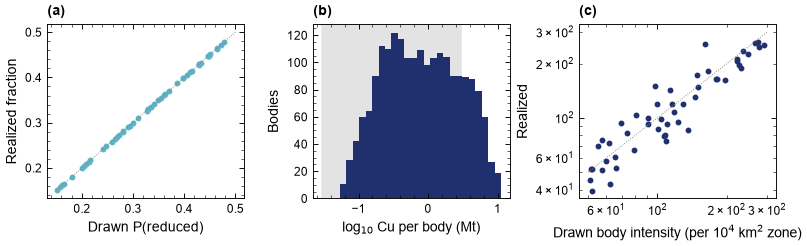

50 realizations: reduced fraction equals the draw (max |diff| 0.000); zone 701-7485 km2 (median 2618); bodies 3-199 (median 24); realizations with no body 0
Cu per body 0.054-11.3 Mt, median 0.77; inside the Mount Gunson range 0.03-3 Mt: 81%; total per realization median 42.9 Mt (the Mount Gunson field: about 3 Mt); bodies at 155-345 m depth (10-90%); median distance from the facies edge 2.0 km


In [8]:
rows, all_ore = [], []
for s in range(1000, 1050):
    o, _, _, e = realize_mg(s); rows.append(o)
    if len(e): all_ore.append(e.assign(seed=s))
EN = pd.DataFrame(rows); ORES = pd.concat(all_ore, ignore_index=True) if all_ore else pd.DataFrame()
EN.to_csv(OUT / "wp4_prior_draws_mg_n50.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.4)); fig.subplots_adjust(left=0.07, right=0.99, top=0.88, bottom=0.22, wspace=0.35)
ax = axes[0]; ax.scatter(EN["C3-1 p_reduced"], EN.reduced_frac, s=8, color=C_MG["reduced"]); ax.plot([0.15, 0.5], [0.15, 0.5], color="0.5", lw=0.6, ls=":"); ax.set_xlabel("Drawn P(reduced)"); ax.set_ylabel("Realized fraction")
ax = axes[1]
if len(ORES): ax.hist(np.log10(ORES.Mt), bins=25, color=C_MG["ore"]); ax.axvspan(np.log10(0.03), np.log10(3), color=C.ANNEX_GREY, zorder=0)
ax.set_xlabel("log$_{10}$ Cu per body (Mt)"); ax.set_ylabel("Bodies")
ax = axes[2]; ax.scatter(EN["C4-2 body_intensity_per_1e4km2"], EN.n_ore / np.maximum(EN.zone_km2, 1) * 1e4, s=8, color=C_MG["ore"]); ax.plot([50, 300], [50, 300], color="0.5", lw=0.6, ls=":"); ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Drawn body intensity (per 10$^4$ km$^2$ zone)"); ax.set_ylabel("Realized")
panel_labels(axes, ("(a)", "(b)", "(c)")); fig.savefig(FIG / "wp4_MG_04_ensemble_checks.png", dpi=300); plt.show()
print(f"50 realizations: reduced fraction equals the draw (max |diff| {abs(EN['C3-1 p_reduced'] - EN.reduced_frac).max():.3f}); zone {EN.zone_km2.min():.0f}-{EN.zone_km2.max():.0f} km2 (median {EN.zone_km2.median():.0f}); bodies {EN.n_ore.min()}-{EN.n_ore.max()} (median {EN.n_ore.median():.0f}); realizations with no body {(EN.n_ore == 0).sum()}")
if len(ORES): print(f"Cu per body {ORES.Mt.min():.3f}-{ORES.Mt.max():.1f} Mt, median {ORES.Mt.median():.2f}; inside the Mount Gunson range 0.03-3 Mt: {((ORES.Mt >= 0.03) & (ORES.Mt <= 3)).mean()*100:.0f}%; total per realization median {EN.Mt_total.median():.1f} Mt (the Mount Gunson field: about 3 Mt); bodies at {ORES.depth_m.quantile(0.1):.0f}-{ORES.depth_m.quantile(0.9):.0f} m depth (10-90%); median distance from the facies edge {ORES.dist_edge_km.median():.1f} km")


**Reading the figure.** (a) Realized reduced fraction against the drawn P (equal by construction). (b) Cu per body against the Mount Gunson range (grey, 0.03 to 3 Mt). (c) Realized body count per zone area against the drawn intensity.
- 50 realizations: zone 700 to 7,500 km$^2$ (median 2,600), 3 to 199 bodies (median 24), none without; bodies at 155 to 345 m depth (10 to 90%), median 2.0 km inside the facies edge.
- Cu per body 0.05 to 11 Mt, median 0.8; 81% inside the Mount Gunson range. Total per realization median 43 Mt against the Mount Gunson field's 3 Mt: the prior says the window holds of order twenty Mount Gunson fields, which is what C4-2 and C3-1 together imply and what the record cannot confirm or deny. These two rows are the ones whose sensitivity to report.

## Part B. Prior predictive check

Imported rule, operator and surveys. Nothing in this branch produces an anomaly, so the gate tests the shared setting and the barren objects, the same population as the other branches apart from the basement-field draws; it is run so that the record is complete and the branch's ensemble can be compared on equal terms.

### Step 5. One realization against the surveys (seed 43)

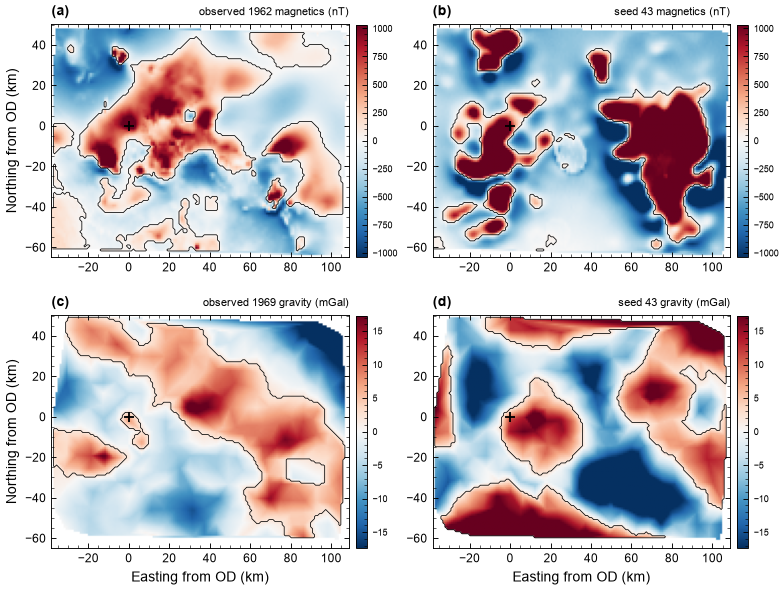

gravity   observed {'n_per_1e4km2': 1.98, 'amp_median': 18.06, 'amp_p90': 20.61, 'width_median_km': 27.87, 'residual_sd': 7.53}
          seed 43  {'n_per_1e4km2': 2.64, 'amp_median': 24.98, 'amp_p90': 31.11, 'width_median_km': 42.66, 'residual_sd': 12.35}
magnetics observed {'n_per_1e4km2': 9.45, 'amp_median': 263.29, 'amp_p90': 2440.61, 'width_median_km': 7.82, 'residual_sd': 440.41}
          seed 43  {'n_per_1e4km2': 10.08, 'amp_median': 358.75, 'amp_p90': 4107.74, 'width_median_km': 6.23, 'residual_sd': 897.86}


In [9]:
OBS_G, GRID_G, ANOM_G = C.anomaly_stats(C.TRI_G, C.GXo, C.GYo, C.G_OBS, C.RULE["T_grav_mgal"])
OBS_M, GRID_M, ANOM_M = C.anomaly_stats(C.TRI_M, C.MXo, C.MYo, C.M_OBS, C.RULE["T_mag_nt"])
_, _, _, _, gs43, ms43 = synthetic_mg(43)
SYN_G43, SG, SA = C.anomaly_stats(C.TRI_G, C.GXo, C.GYo, gs43, C.RULE["T_grav_mgal"]); SYN_M43, SM, SMA = C.anomaly_stats(C.TRI_M, C.MXo, C.MYo, ms43, C.RULE["T_mag_nt"])
fig, axes = plt.subplots(2, 2, figsize=(COL2, 5.6)); fig.subplots_adjust(left=0.07, right=0.97, top=0.93, bottom=0.08, wspace=0.15, hspace=0.25)
lim_g = np.nanpercentile(abs(GRID_G), 98); lim_m = np.nanpercentile(abs(GRID_M), 98)
for ax, grid, anom, lim, lab in [(axes[0, 0], GRID_M, ANOM_M, lim_m, "observed 1962 magnetics (nT)"), (axes[0, 1], SM, SMA, lim_m, "seed 43 magnetics (nT)"),
                                 (axes[1, 0], GRID_G, ANOM_G, lim_g, "observed 1969 gravity (mGal)"), (axes[1, 1], SG, SA, lim_g, "seed 43 gravity (mGal)")]:
    im = ax.imshow(grid, origin="lower", extent=ext, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="equal")
    ax.contour(xkm, (YC - ODY) / 1e3, anom.astype(float), levels=[0.5], colors="k", linewidths=0.5)
    ax.plot(0, 0, "+", color="k", ms=7, mew=1.2); ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_title(lab, fontsize=FS_ANNOT, loc="right")
    cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02); cb.ax.tick_params(labelsize=FS_ANNOT - 1)
for ax in axes[1]: ax.set_xlabel("Easting from OD (km)")
for ax in axes[:, 0]: ax.set_ylabel("Northing from OD (km)")
panel_labels(axes.ravel(), ("(a)", "(b)", "(c)", "(d)")); fig.savefig(FIG / "wp4_MG_05_observed_vs_seed43.png", dpi=300); plt.show()
show = lambda s: {k: round(float(v), 2) for k, v in s.items()}
print("gravity   observed", show(OBS_G)); print("          seed 43 ", show(SYN_G43)); print("magnetics observed", show(OBS_M)); print("          seed 43 ", show(SYN_M43))


**Reading the figure.** Plane-removed residuals, black outlines the anomalies the rule detects. Seed 43's anomalies come from the shared basement fields, the barren piles and the iron bodies; the copper bodies contribute nothing, which is the point of the branch.
- Seed 43 against the survey: gravity 2.6 anomalies per 10$^4$ km$^2$ (observed 2.0), median peak 25.0 mGal (18.1), 90th percentile 31.1 (20.6), median width 43 km (28), residual sd 12.4 (7.5); magnetics 10.1 per 10$^4$ km$^2$ (9.5), median peak 359 nT (263), 90th percentile 4,108 (2,441), width 6.2 km (7.8), residual sd 898 (440). This seed draws the top of the basement-density range; the ensemble is what the gate judges.

### Step 6. The predictive ensemble

200 realizations (seeds 1000 to 1199), forward-modelled with noise, sampled at the stations and readings, scored with the rule; predictions kept for Step 8. Cached in `pp_chunks/`.

In [10]:
N_ENS, SEED0 = 200, 1000
PPC = OUT / "pp_chunks"; PPC.mkdir(exist_ok=True); CH = 50
KEY = f"mg_v01_{C.NX}x{C.NY}"
t0 = time.time(); rows = []; PRED_G, PRED_M = [], []
for c0 in range(SEED0, SEED0 + N_ENS, CH):
    f = PPC / f"pp_{KEY}_{c0}_{c0 + CH - 1}.npz"
    if f.exists():
        z = np.load(f, allow_pickle=True); rows += list(z["rows"]); PRED_G += list(z["pred_g"]); PRED_M += list(z["pred_m"]); continue
    crows, cpg, cpm = [], [], []
    for s in range(c0, c0 + CH):
        o, mp, g, t, gs, ms = synthetic_mg(s)
        sg, _, _ = C.anomaly_stats(C.TRI_G, C.GXo, C.GYo, gs, C.RULE["T_grav_mgal"]); sm, _, _ = C.anomaly_stats(C.TRI_M, C.MXo, C.MYo, ms, C.RULE["T_mag_nt"])
        crows.append({**o, **{"g_" + k: v for k, v in sg.items()}, **{"m_" + k: v for k, v in sm.items()}}); cpg.append(gs.astype(np.float32)); cpm.append(ms.astype(np.float32))
    np.savez_compressed(f, rows=np.array(crows, dtype=object), pred_g=np.array(cpg), pred_m=np.array(cpm))
    rows += crows; PRED_G += cpg; PRED_M += cpm
    print(f"  seeds {c0}-{c0 + CH - 1} done, {time.time() - t0:.0f} s", flush=True)
PRED_G, PRED_M = np.array(PRED_G), np.array(PRED_M)
PP = pd.DataFrame(rows); PP.to_csv(OUT / "wp4_prior_predictive_stats_mg_n200.csv", index=False)
print(f"{N_ENS} realizations in {time.time() - t0:.0f} s; predicted gravity {PRED_G.shape}, magnetics {PRED_M.shape}")


  seeds 1000-1049 done, 44 s
  seeds 1050-1099 done, 88 s
  seeds 1100-1149 done, 134 s
  seeds 1150-1199 done, 178 s
200 realizations in 178 s; predicted gravity (200, 398), magnetics (200, 37095)


### Step 7. The gate

The five statistics per survey and the verdicts of the sediment-hosted Step 12. Written to `wp4_prior_predictive_gate_mg.csv`.

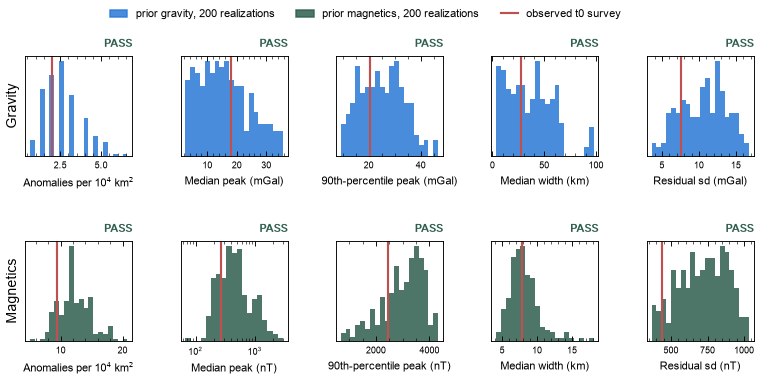

    field       statistic  observed  sim_p05  sim_median  sim_p95  sim_min  sim_max  quantile status
  gravity    n_per_1e4km2     1.981    1.321       2.642    4.623    0.660    6.605     0.312   PASS
  gravity      amp_median    18.059    4.019      14.843   31.341    2.547   35.611     0.630   PASS
  gravity         amp_p90    20.613   12.816      24.989   37.722    9.285   46.697     0.340   PASS
  gravity width_median_km    27.869    6.770      35.273   67.709    3.568   97.629     0.400   PASS
  gravity     residual_sd     7.527    5.615      10.889   15.295    3.590   16.759     0.195   PASS
magnetics    n_per_1e4km2     9.452    8.192      11.972   17.013    5.041   20.794     0.140   PASS
magnetics      amp_median   263.288  186.765     435.753 1401.626   74.415 2673.125     0.225   PASS
magnetics         amp_p90  2440.613 1475.799    3210.693 3972.429  686.656 4324.917     0.225   PASS
magnetics width_median_km     7.818    5.285       7.736   11.930    4.145   18.083     0.5

In [11]:
STATS = [("n_per_1e4km2", "Anomalies per 10$^4$ km$^2$", False), ("amp_median", "Median peak", True), ("amp_p90", "90th-percentile peak", True), ("width_median_km", "Median width (km)", False), ("residual_sd", "Residual sd", True)]
UNIT = {"g": "mGal", "m": "nT"}
def gate(sim, obs):
    sim = np.asarray(sim, float); sim = sim[np.isfinite(sim)]; tie = np.isclose(sim, obs, rtol=1e-9, atol=0)
    q = (sim < obs)[~tie].sum() / len(sim) + 0.5 * tie.mean()
    return q, "PASS" if 0.05 <= q <= 0.95 else ("WARN" if sim.min() <= obs <= sim.max() else "FAIL")
GATE = []
fig, axes = plt.subplots(2, 5, figsize=(COL2, 3.6)); fig.subplots_adjust(left=0.07, right=0.99, top=0.86, bottom=0.14, wspace=0.45, hspace=0.85)
for r_, (f, obs, col) in enumerate([("g", OBS_G, "#2a78d6"), ("m", OBS_M, "#2e5e4e")]):
    for c, (key, lab, unit) in enumerate(STATS):
        ax = axes[r_, c]; sim = PP[f"{f}_{key}"].dropna(); o = obs[key]; allv = np.r_[sim.values, o]
        logx = unit and allv.min() > 0 and allv.max() / allv.min() > 30
        ax.hist(sim, bins=np.geomspace(allv.min() * 0.9, allv.max() * 1.1, 20) if logx else 20, color=col, alpha=0.85)
        if logx: ax.set_xscale("log")
        ax.axvline(o, color="#c0504d", lw=1.4); q, st = gate(sim, o)
        GATE.append(dict(field={"g": "gravity", "m": "magnetics"}[f], statistic=key, observed=o, sim_p05=np.percentile(sim, 5), sim_median=np.median(sim), sim_p95=np.percentile(sim, 95), sim_min=sim.min(), sim_max=sim.max(), quantile=q, status=st))
        ax.set_title(st, loc="right", fontsize=FS_ANNOT, fontweight="bold", color={"PASS": "#2e5e4e", "WARN": "#eda100", "FAIL": "#c0504d"}[st])
        ax.set_xlabel(lab + (f" ({UNIT[f]})" if unit else ""), fontsize=FS_ANNOT); ax.tick_params(labelsize=FS_ANNOT - 1); ax.set_yticks([])
axes[0, 0].set_ylabel("Gravity", fontsize=FS_LABEL); axes[1, 0].set_ylabel("Magnetics", fontsize=FS_LABEL)
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="#2a78d6", alpha=0.85, label=f"prior gravity, {N_ENS} realizations"), plt.Rectangle((0, 0), 1, 1, color="#2e5e4e", alpha=0.85, label=f"prior magnetics, {N_ENS} realizations"), plt.Line2D([], [], color="#c0504d", lw=1.4, label="observed t0 survey")], loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.0), frameon=False)
fig.savefig(FIG / "wp4_MG_07_gate.png", dpi=300); plt.show()
GATE = pd.DataFrame(GATE); GATE.to_csv(OUT / "wp4_prior_predictive_gate_mg.csv", index=False); print(GATE.round(3).to_string(index=False))


**Reading the figure.** Histograms are the 200 realizations, the red line the survey.
- All ten statistics pass: gravity $q$ 0.20 to 0.63, magnetics $q$ 0.06 to 0.51, the magnetic residual sd nearest the edge ($q$ 0.06; prior median 731 nT against 440), as in the other two branches and for the same reason, the shared basement susceptibility field.
- The verdicts are those of the shared setting with barren piles and iron bodies, matching the sediment-hosted Step 12 up to the basement-field draws, as expected for a branch that adds no anomaly source.

### Step 8. Falsification by robust Mahalanobis distance

As the sediment-hosted Step 15. Written to `wp4_prior_falsification_rmd_mg_n200.csv`.

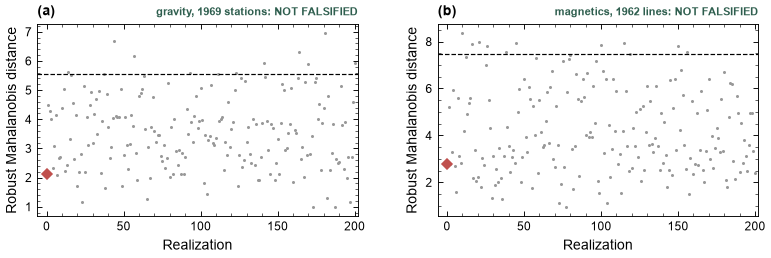

    field  rmd_observed  rmd_p95  observed_percentile  var_captured       verdict
  gravity         2.105    5.566                 11.5         0.744 NOT FALSIFIED
magnetics         2.782    7.460                 25.5         0.253 NOT FALSIFIED
     both         3.855    8.053                 16.0           NaN NOT FALSIFIED


In [12]:
from sklearn.decomposition import PCA
from sklearn.covariance import MinCovDet
N_PCS, Q_RMD = 10, 95
def plane_projector(x, y):
    A = np.c_[np.ones_like(x), (x - C.X0) / 1e3, (y - C.Y0) / 1e3]; return A, np.linalg.pinv(A)
def rmd(V, obs, P, n_pcs=N_PCS, q=Q_RMD):
    A, Ap = P; V = V.astype(np.float64); V -= (V @ Ap.T) @ A.T; o = (obs - (obs @ Ap.T) @ A.T)[None, :]
    lo = np.minimum(V.min(0), o[0]); hi = np.maximum(V.max(0), o[0]); sc = 2 / np.where(hi > lo, hi - lo, 1.0); V = (V - lo) * sc - 1; o = (o - lo) * sc - 1
    pca = PCA(n_components=n_pcs, random_state=0).fit(V); X, Xo = pca.transform(V), pca.transform(o)
    mcd = MinCovDet(random_state=0).fit(X); Pinv = np.linalg.inv(mcd.covariance_)
    md = np.sqrt(np.einsum("ij,jk,ik->i", X - mcd.location_, Pinv, X - mcd.location_)); md_obs = float(np.sqrt((Xo - mcd.location_) @ Pinv @ (Xo - mcd.location_).T).item())
    return dict(evr=pca.explained_variance_ratio_, X=X, Xo=Xo, md=md, md_obs=md_obs, q_md=float(np.percentile(md, q)), pct_obs=float((md < md_obs).mean()))
RMD = {"g": rmd(PRED_G, C.G_OBS, plane_projector(C.GXo, C.GYo)), "m": rmd(PRED_M, C.M_OBS, plane_projector(C.MXo, C.MYo))}
XJ, XJo = np.c_[RMD["g"]["X"], RMD["m"]["X"]], np.c_[RMD["g"]["Xo"], RMD["m"]["Xo"]]
mj = MinCovDet(random_state=0).fit(XJ); Pj = np.linalg.inv(mj.covariance_)
mdj = np.sqrt(np.einsum("ij,jk,ik->i", XJ - mj.location_, Pj, XJ - mj.location_)); mdjo = float(np.sqrt((XJo - mj.location_) @ Pj @ (XJo - mj.location_).T).item())
RMD["j"] = dict(md=mdj, md_obs=mdjo, q_md=float(np.percentile(mdj, Q_RMD)), pct_obs=float((mdj < mdjo).mean()), evr=np.array([np.nan]))
FALS = pd.DataFrame([dict(field={"g": "gravity", "m": "magnetics", "j": "both"}[f], rmd_observed=RMD[f]["md_obs"], rmd_p95=RMD[f]["q_md"], observed_percentile=100 * RMD[f]["pct_obs"],
                          var_captured=float(np.nansum(RMD[f]["evr"])) if f != "j" else np.nan, verdict="FALSIFIED" if RMD[f]["md_obs"] > RMD[f]["q_md"] else "NOT FALSIFIED") for f in ("g", "m", "j")])
FALS.to_csv(OUT / "wp4_prior_falsification_rmd_mg_n200.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.6)); fig.subplots_adjust(left=0.08, right=0.99, top=0.85, bottom=0.18, wspace=0.25)
for ax, f, lab in [(axes[0], "g", "gravity, 1969 stations"), (axes[1], "m", "magnetics, 1962 lines")]:
    r_ = RMD[f]; n = len(r_["md"]); ax.scatter(np.arange(1, n + 1), r_["md"], s=4, color="0.6", lw=0); ax.axhline(r_["q_md"], color="k", lw=0.8, ls="--"); ax.plot(0, r_["md_obs"], "D", color="#c0504d", ms=5, zorder=5)
    v = FALS.verdict[["g", "m"].index(f)]; ax.set_title(f"{lab}: {v}", loc="right", fontsize=FS_ANNOT, fontweight="bold", color={"NOT FALSIFIED": "#2e5e4e", "FALSIFIED": "#c0504d"}[v])
    ax.set_xlabel("Realization"); ax.set_ylabel("Robust Mahalanobis distance"); ax.set_xlim(-6, n + 2)
panel_labels(axes, ("(a)", "(b)")); fig.savefig(FIG / "wp4_MG_08_rmd_falsification.png", dpi=300); plt.show()
print(FALS.round(3).to_string(index=False))


**Reading the figure.** Grey dots the 200 realizations, dashed their 95th percentile, red diamond the survey.
- Not falsified: gravity RMD 2.10 against a 95th percentile of 5.40 (the survey at the 13th percentile of the realizations), magnetics 2.67 against 6.76 (29th), both together 3.77 against 7.93 (14th); 74% and 25% of the variance in the 10 components.
- Beside the sediment-hosted (2.51 / 5.75, 2.61 / 7.11) and Middleback (2.29 / 6.24, 2.12 / 6.98) branches: three concepts, one distance from the surveys. The t0 data rank none of them; the first hole does.

## Part C. Versioned record

### Step 9. The record

In [13]:
sha = lambda path: hashlib.sha256(Path(path).read_bytes()).hexdigest()[:12]
VA = json.loads(Path("08_prior_models/wp4_prior_version.json").read_text()) if Path("08_prior_models/wp4_prior_version.json").exists() else {}
VERSION = {"prior": "WP4 Annex C, Mount Gunson-type stratiform Cu branch", "version": "0.1",
           "status": "v0.1 (2026-10-07): scaffold. Level 3 the Woocalla reduced facies at the top of the Pandurra with a depression term; Level 4 tabular Cu bodies within reach of the facies edge; rows C3-1 to C4-4 translated from mount_gunson_t0_dossier.csv, all 'to elicit'; C5-1 derived. Shared setting imported from svoi_core (Annex A " + VA.get("version", "?") + ", Change 9). Invisible to both surveys by construction.",
           "built_against_annexA": {"version": VA.get("version"), "citation_table_sha": VA.get("citation_table_sha")},
           "annexC_table_sha": sha("01_citation_table/wp4_annexC_citation_table_draft.csv"), "core_sha": sha("09_sherlock/svoi_core.py"),
           "t0": "1975-05-02", "built": str(datetime.date.today()),
           "seed_convention": "numpy default_rng(seed); C.draw first (shared rows, same stream as Annex A), the Annex C rows drawn inside their stages; synthetic noise default_rng(seed + 10,000,000)",
           "seeds": {"figures": [43, 77, 99], "row_check": [1000, 1049], "predictive_check": [SEED0, SEED0 + N_ENS - 1]},
           "declared_settings": FIX_MG, "section4_rule": C.RULE,
           "section4_gate": GATE.groupby(["field", "status"]).size().unstack(fill_value=0).to_dict(orient="index"),
           "falsification_rmd": {r.field: dict(verdict=r.verdict, rmd_observed=round(r.rmd_observed, 3), rmd_p95=round(r.rmd_p95, 3)) for r in FALS.itertuples()}}
TAG = f"WP4-C-MG v{VERSION['version']} ({VERSION['annexC_table_sha']})"
(OUT / "wp4_prior_version_mountgunson.json").write_text(json.dumps(VERSION, indent=2, default=float))
print("prior version tag:", TAG); print(json.dumps(VERSION, indent=2, default=float))


prior version tag: WP4-C-MG v0.1 (d0cb7a329032)
{
  "prior": "WP4 Annex C, Mount Gunson-type stratiform Cu branch",
  "version": "0.1",
  "status": "v0.1 (2026-10-07): scaffold. Level 3 the Woocalla reduced facies at the top of the Pandurra with a depression term; Level 4 tabular Cu bodies within reach of the facies edge; rows C3-1 to C4-4 translated from mount_gunson_t0_dossier.csv, all 'to elicit'; C5-1 derived. Shared setting imported from svoi_core (Annex A 0.10, Change 9). Invisible to both surveys by construction.",
  "built_against_annexA": {
    "version": "0.10",
    "citation_table_sha": "e74b866aeff0"
  },
  "annexC_table_sha": "d0cb7a329032",
  "core_sha": "ebf85a7eeae2",
  "t0": "1975-05-02",
  "built": "2026-10-07",
  "seed_convention": "numpy default_rng(seed); C.draw first (shared rows, same stream as Annex A), the Annex C rows drawn inside their stages; synthetic noise default_rng(seed + 10,000,000)",
  "seeds": {
    "figures": [
      43,
      77,
      99
    ],
  

## Summary

1. The Mount Gunson branch is the third concept on the shared setting: for any seed, Level 1 and the piles are those of the other two branches, and the surveys see the same barren objects.
2. Its Level 3 is the one facies that was actually drilled on the shelf before 1975, placed where the record puts it, at the top of the Pandurra in depressions of that surface; its Level 4 is the Mount Gunson rule, tabular copper within reach of the facies edge, at Mount Gunson sizes (0.05 to 10 Mt per body) and grades (1 to 3.5% Cu).
3. The branch makes no anomaly, so the gate and the falsification test are those of the shared setting, and the t0 Bayes factor against the other branches is one by construction: under this concept the surveys do not help find copper on the shelf, and only drilling the facies near its edge does.
4. Every C row is marked *to elicit* and must be confirmed against its source; the depression weight and window are declared.

Next: confirm the rows; the Sherlock twin folder for the 10,000-member run; the three-branch comparison on district statistics and, after it, on drilling.